# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
# Your code here. 

student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

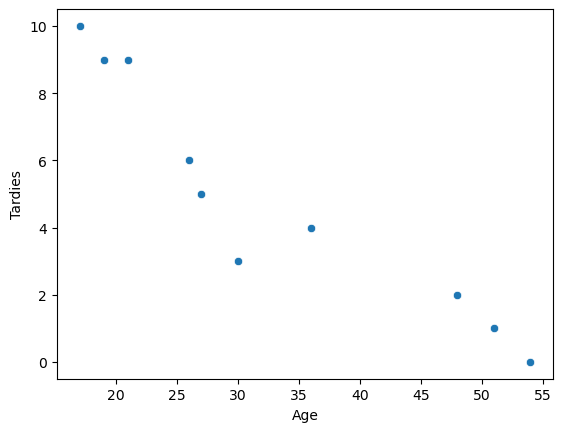

In [4]:
# Your code here
sns.scatterplot(x= student_data['Age'], y=student_data['Tardies'])
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*

##### Generally with the increasing age, the decresed Tardies can be obtained.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [57]:
# your code 
# covariance: tell the direction, 
cov = np.cov(student_data['Age'],student_data['Tardies'])[0,1]
print(cov)
# Negative direction.

-45.56666666666666


In [58]:
# correlation: how 2 parameters affect each other
corr = np.corrcoef(student_data['Age'], student_data['Tardies'])[0,1]
print(corr)
## strong negative direction, since value is -0.93.

-0.9391626886887122


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [13]:
# your explanation here
# y would be variable

#split
from sklearn.model_selection import train_test_split
X = student_data[['Age']]
y = student_data['Tardies']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
# linear regression model
from sklearn.linear_model import LinearRegression
lm= LinearRegression()
lm.fit(X_train, y_train)
y_predict = lm.predict(X_test)
print( y_predict)

[-0.93093923 -0.13121547]


Plot your regression model on your scatter plot.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


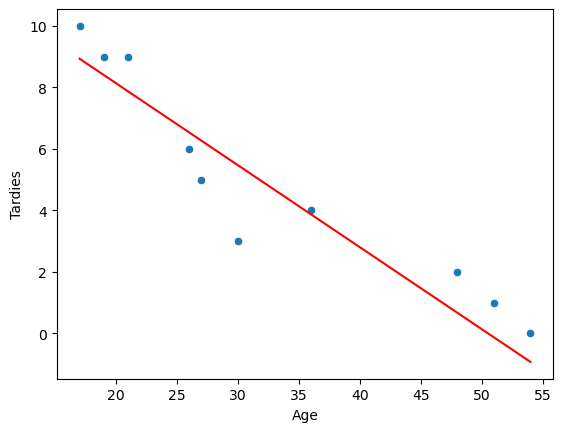

In [27]:
# Your code here.
sns.scatterplot(x= student_data['Age'], y=student_data['Tardies'])
X_l = np.arange(student_data['Age'].min(), student_data['Age'].max()+1).reshape(-1,1)
y_l= lm.predict(X_l)
plt.plot(X_l, y_l, color = 'r')
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

*your explanation here*

Answer: 
There is linear relationship. Based on the strong correlation, yes we can predict. As age increases, tardies tends to decrease.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [30]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("/Users/baojianing/Desktop/DS ML 2026 June_J Bao/4_week/D_4/lab/lab-regression-analysis-en/vehicles.csv")

In [32]:
veh = vehicles.copy ()
veh.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [54]:
# Your code here. 
# y = CO2 Emission Grams/Mile
corr1 = np.corrcoef(veh['Year'], veh['CO2 Emission Grams/Mile'])[0,1]
corr2 = np.corrcoef(veh["Fuel Barrels/Year"], veh['CO2 Emission Grams/Mile'])[0,1]
corr3 = np.corrcoef(veh['Combined MPG'], veh['CO2 Emission Grams/Mile'])[0,1]
corr4 = np.corrcoef(veh['Fuel Cost/Year'], veh['CO2 Emission Grams/Mile'])[0,1]

print(f'the correlation between year and CO2 Emission Grams/Mile is: {corr1:.4f}\n'
      f'the correlation between Fuel Barrels/Year and CO2 Emission Grams/Mile is: {corr2:.4f}\n'
      f'the correlation between Combined MPG and CO2 Emission Grams/Mile is: {corr3:.4f}\n'
      f'the correlation between Fuel Cost/Year and CO2 Emission Grams/Mile is: {corr4:.4f}\n'
      )

the correlation between year and CO2 Emission Grams/Mile is: -0.2223
the correlation between Fuel Barrels/Year and CO2 Emission Grams/Mile is: 0.9862
the correlation between Combined MPG and CO2 Emission Grams/Mile is: -0.9262
the correlation between Fuel Cost/Year and CO2 Emission Grams/Mile is: 0.9309



In [ ]:
''' we  need to consider the absolute value. 
Here the largest is Fuel Barrels/Year, 0.9862, so is the strongst one.
Hence, year is the least helpful
'''

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [ ]:
# Your code here.
# multiregression, because we have more than one variable to be compared.
X= veh[['Year','Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']]
y = veh['CO2 Emission Grams/Mile']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state= 42)
lm = LinearRegression()
lm.fit(X_train, y_train)
y_predict = lm.predict(X_test)
y_predict

array([342.43684531, 517.7479553 , 436.61861496, ..., 480.89793101,
       471.45798221, 588.48721744], shape=(7191,))

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [69]:
# Your code here.
import statsmodels.api as sm
est = sm.OLS(y_train, X_train) # Creates an object OLS estimator
est = est.fit()
est.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     CO2 Emission Grams/Mile   R-squared (uncentered):                   0.999
Model:                                 OLS   Adj. R-squared (uncentered):              0.999
Method:                      Least Squares   F-statistic:                          6.182e+06
Date:                     Thu, 09 Jul 2026   Prob (F-statistic):                        0.00
Time:                             17:08:40   Log-Likelihood:                     -1.2178e+05
No. Observations:                    28761   AIC:                                  2.436e+05
Df Residuals:                        28757   BIC:                                  2.436e+05
Df Model:                                4                                                  
Covariance Type:                 nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Year                  0.0611      0.001     65.229      0.000       0.059       0.063
Fuel Barrels/Year    20.0816      0.066    306.547      0.000      19.953      20.210
Combined MPG         -2.9411      0.048    -61.527      0.000      -3.035      -2.847
Fuel Cost/Year        0.0307      0.001     60.740      0.000       0.030       0.032
==============================================================================
Omnibus:                    59750.763   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        277788818.006
Skew:                          17.756   Prob(JB):                         0.00
Kurtosis:                     483.149   Cond. No.                     2.04e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
#absolute value of t: the largest one: Fuel Barrels/year
## R squred is 0.99, the model is very reliable.

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [74]:
# Your code here.
inv = pd.DataFrame({'X':[1,3,4,6,8,9,11,14], 'Y': [1,2,4,4,5,7,8,13]})
inv

,X,Y
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5
5,9,7
6,11,8
7,14,13


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

[2.16167665 7.24550898]


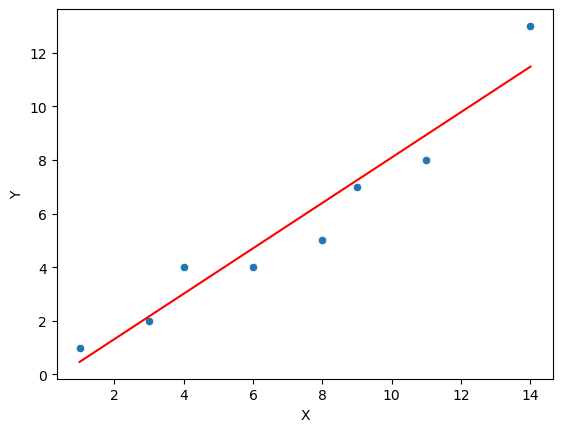

In [83]:
# Your code here.
sns.scatterplot(data=inv, x= 'X', y= 'Y')

X = inv[['X']]
y = inv['Y']

X_tr, X_tst, y_tr, y_tst = train_test_split(X, y, test_size= 0.2, random_state= 42)
# linear regression model

lm_inv= LinearRegression()
lm_inv.fit(X_tr, y_tr)
y_inv_predict = lm_inv.predict(X_tst)
print( y_inv_predict) # for evaluation
y_inv_all= lm_inv.predict(X) # for plot
plt.plot(X, y_inv_all, 'r') 
plt.show()

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

In [ ]:
# There is a trend with positive slope: If "I" invited more people, more people will attend.

forprint = sm.OLS(y_tr, X_tr) # Creates an object OLS estimator
forprint = forprint.fit()
forprint.summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      Y   R-squared (uncentered):                   0.976
Model:                            OLS   Adj. R-squared (uncentered):              0.971
Method:                 Least Squares   F-statistic:                              199.2
Date:                Thu, 09 Jul 2026   Prob (F-statistic):                    3.22e-05
Time:                        17:52:17   Log-Likelihood:                         -9.0299
No. Observations:                   6   AIC:                                      20.06
Df Residuals:                       5   BIC:                                      19.85
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
X              0.8088      0.057     14.112      0.000       0.661       0.956
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.181
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.503
Skew:                           0.356   Prob(JB):                        0.778
Kurtosis:                       1.773   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

*your explanation here*

##### The sample size is too small. But considering R-Squared, the model is reliable, and P>|t| is close to 0.000, which indicates that reject H0, so they have significant relationship inbetween. 

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

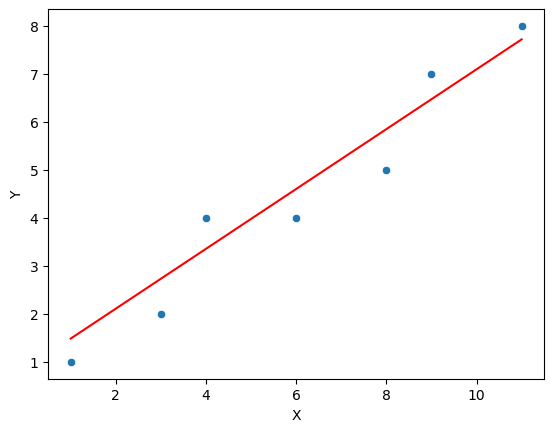

In [95]:
# Your response here.
# Yes. The last one.
inv_new = inv.iloc[:-1]

X = inv_new[["X"]]
y = inv_new['Y']
X_tr_new, X_test_new, y_tr_new, y_tst_new = train_test_split(X, y, test_size= 0.2, random_state= 42)
lm_inv_new = LinearRegression()
lm_inv_new.fit(X_tr_new, y_tr_new)
y_inv_all_new = lm_inv_new.predict(X)
sns.scatterplot(data= inv_new, x= 'X', y= 'Y')
plt.plot(X, y_inv_all_new, 'r')
plt.show()



What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*

In [93]:
print(f'slope of original data is: {lm_inv.coef_}')        
print(f'b of orig. data is: {lm_inv.intercept_:.3f}')   
print(f'slope of new data is: {lm_inv_new.coef_}')        
print(f'b of new data is: {lm_inv_new.intercept_:.3f}')   

slope of original data is: [0.84730539]
b of orig. data is: -0.380
slope of new data is: [0.62328767]
b of new data is: 0.863


In [ ]:
##The slope and intercept has been changed.  